# VDF Generation

Date Created: 12-Nov-2025

Date Modified: 10-Dec-2025

Author: Regis John

In [1]:
import numpy as np
import pyspedas
from pyspedas.projects import mms

In [2]:
trange = ['2015-12-09/05:03:55', '2015-12-09/05:03:59']

## Spacecraft Pontential Correction
Reading in particle energy data:

In [3]:
fpi_vars = mms.fpi(trange= trange, probe='1', data_rate='brst',level='l2',
        datatype='des-dist', time_clip=True, varnames=['mms1_des_energy_brst'], 
        get_support_data=True)

10-Dec-25 08:19:30: Loading files for group: probe: 1, drate: brst, level: l2, datatype: des-dist, after sorting and filtering:
10-Dec-25 08:19:30: /Users/rejohn/Data_Speedas/mms/mms1/fpi/brst/l2/des-dist/2015/12/09/mms1_fpi_brst_l2_des-dist_20151209050044_v3.3.0.cdf
10-Dec-25 08:19:30: The name mms1_des_errorflags_brst is currently not in pyspedas
10-Dec-25 08:19:30: The name mms1_des_compressionloss_brst is currently not in pyspedas
10-Dec-25 08:19:30: The name mms1_des_pitchangdist_lowen_brst is currently not in pyspedas
10-Dec-25 08:19:30: The name mms1_des_pitchangdist_miden_brst is currently not in pyspedas
10-Dec-25 08:19:30: The name mms1_des_pitchangdist_highen_brst is currently not in pyspedas
10-Dec-25 08:19:30: The name mms1_des_errorflags_brst_dist is currently not in pyspedas
10-Dec-25 08:19:30: The name mms1_des_errorflags_brst_dist is currently not in pyspedas
10-Dec-25 08:19:30: The name mms1_des_compressionloss_brst_moms is currently not in pyspedas
10-Dec-25 08:19:30

Reading in spacecraft potential data:

In [4]:
edp_vars = mms.edp(trange=trange, probe=1, data_rate='brst', level='l2',
                            datatype='scpot', time_clip=True,
                            varnames='mms1_edp_scpot_brst_l2')

10-Dec-25 08:19:31: Loading files for group: probe: 1, drate: brst, level: l2, datatype: scpot, after sorting and filtering:
10-Dec-25 08:19:31: /Users/rejohn/Data_Speedas/mms/mms1/edp/brst/l2/scpot/2015/12/09/mms1_edp_brst_l2_scpot_20151209050044_v2.4.0.cdf


In [5]:
pyspedas.tplot_rename('mms1_des_energy_brst', 'nrgy')
pyspedas.tplot_rename('mms1_edp_scpot_brst_l2', 'scpot')

### Downsampling spacecraft potential to DES cadence of 30 ms

In [6]:
times, nrgy = pyspedas.get_data('nrgy')
_, scpot = pyspedas.get_data('scpot')

In [7]:
times.shape, nrgy.shape, scpot.shape

((133,), (133, 32), (32768,))

In [10]:
nrgy_mtdata = pyspedas.get_data("nrgy", metadata=True)

In [11]:
nrgy_mtdata

{'CDF': {'VATT': {'CATDESC': 'MMS FPI/DES burst sky-map parity 0/1 energies',
   'COORDINATE_SYSTEM': 'DBCS>Despun Body Coordinate System',
   'DELTA_PLUS_VAR': 'mms1_des_energy_delta_brst',
   'DELTA_MINUS_VAR': 'mms1_des_energy_delta_brst',
   'DEPEND_0': 'Epoch',
   'FIELDNAM': 'MMS/FPI energy',
   'FILLVAL': np.float32(-1e+31),
   'FORMAT': 'E12.2',
   'LABLAXIS': 'energy',
   'REPRESENTATION_1': 'r',
   'SCALETYP': 'log',
   'SI_CONVERSION': '1.6021773E-19>J',
   'UNITS': 'eV',
   'VALIDMIN': np.float32(0.0),
   'VALIDMAX': np.float32(30000.0),
   'VAR_NOTES': 'Energies (parity 0/1) in the 64-step FPI energy table',
   'VAR_TYPE': 'support_data'},
  'GATT': {'Project': ['STP>Solar-Terrestrial Physics'],
   'Source_name': ['MMS1>MMS Satellite Number 1'],
   'Discipline': ['Space Physics>Magnetospheric Science'],
   'Data_type': ['brst_l2_des-dist'],
   'Descriptor': ['DES>Dual Electron Spectrometers'],
   'File_naming_convention': ['source_descriptor_datatype_yyyyMMddHHmmss'],
   '

In [11]:
# Define target cadence
des_cadence = 0.03  # seconds or 30 ms

In [12]:
# 1. Downsample spacecraft potential (native 8192 Hz → 33 Hz)
pyspedas.avg_data('scpot', res=des_cadence, newname='scpot_avg')

14-Nov-25 22:42:51: avg_data was applied to: scpot_avg


['scpot_avg']

Subtracting spacecraft potential from particle energy data:

In [13]:
times, nrgy = pyspedas.get_data('nrgy')
_, scpot = pyspedas.get_data('scpot_avg')

In [14]:
nrgy.shape, scpot.shape

((133, 32), (133,))

In [15]:
scpot_reshaped = np.repeat(scpot[:, np.newaxis], 32, axis=1)  # shape: (N, 32)

In [44]:
q = -1 # electron charge

In [ ]:
nrgy_corr = nrgy + q * scpot_reshaped

In [17]:
nrgy_corr.shape, scpot_reshaped.shape

((133, 32), (133, 32))

Storing the 16th bin for testing:

In [31]:
pyspedas.store_data('nrgy', data={'x': times, 'y': nrgy[:,16]}, attr_dict={'y': {'units': 'eV', 'label': "Energy (eV) (GSE)"}})
pyspedas.set_coords('nrgy', 'gse')

14-Nov-25 22:58:35: Setting coordinate system for nrgy


True

In [ ]:
pyspedas.store_data('nrgy_corr', data={'x': times, 'y': nrgy_corr[:,16]}, attr_dict={'y': {'units': 'eV', 'label': "Energy SC corrected (eV) (GSE)"}})
pyspedas.set_coords('nrgy_corr', 'gse')

14-Nov-25 22:58:03: Setting coordinate system for nrgy_corr


True

In [30]:
pyspedas.store_data('scpot_reshaped', data={'x': times, 'y': scpot_reshaped[:,16]}, attr_dict={'y': {'units': 'eV', 'label': "Reshaped spacecraft potential(eV) (GSE)"}})
pyspedas.set_coords('scpot_reshaped', 'gse')

14-Nov-25 22:58:13: Setting coordinate system for scpot_reshaped


True

In [32]:
# Combine the two tplot variables of corrected and uncorrected energy
pyspedas.store_data('combined_nrgy', data=['nrgy', 'nrgy_corr'])

True

In [48]:
pyspedas.options('scpot_reshaped', 'legend_names', ['Downsampled Spacecraft Potential $(eV)$'])
pyspedas.options('scpot_reshaped', 'ytitle', 'Potential $(eV)$')

In [49]:
# Set legend names
pyspedas.options('combined_nrgy', 'legend_names', ['Energy $(eV)$',
                                                   'Energy SC corrected $(eV)$'])

# Set line colors
pyspedas.options('combined_nrgy', 'colors', ['black', 'red'])

# Set line styles (0: solid, 1: dashed, 2: dotted, 3: dash_dot)
pyspedas.options('combined_nrgy', 'line_style', ['solid_line', 'dashed'])

# Set line width
pyspedas.options('combined_nrgy', 'line_width', 1.5)

# Set y-axis label
pyspedas.options('combined_nrgy', 'ytitle', 'Energy $(eV)$')

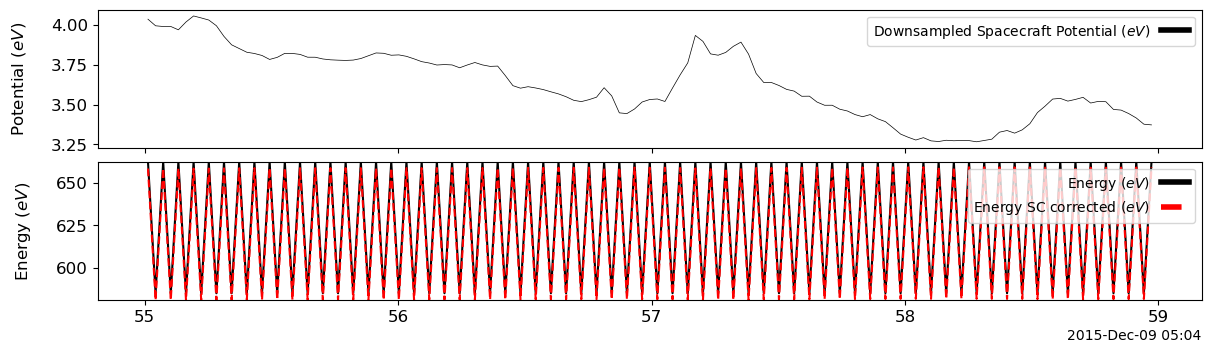

In [51]:
pyspedas.tplot(['scpot_reshaped', 'combined_nrgy'], xsize=12, ysize=3.5, 
               save_png='Nov12_Spacecraft_Potential_Correction.png')

In [ ]:
import numpy as np

def is_2darr_rep(array):
    array0 = array[0, :]  # Get the first column of the array
    testarray = np.tile(array0, (array.shape[0], 1))  # Replicate the first column
    check = np.allclose(array, testarray, atol=1e-6)  # Check if the arrays are close
    return int(check)

In [ ]:
def make_vbin_simple(scpotcorr, interleave, species='e'):
    vbinfactor = 938.272e6 if species == 'i' else 0.51099895e6
    
    if interleave:  # interleaved → two grids
        grids = scpotcorr[0:2, :]   # first even and odd slices
    else:           # not interleaved → one grid
        grids = scpotcorr[0:1, :]   # just the first slice
    
    # Convert to velocity bins (km/s)
    vbin = np.sqrt(2.0 * grids / vbinfactor) * 3e5  # c=3e5 km/s
    return vbin.T   # shape (nbins,1) or (nbins,2)


In [ ]:
import numpy as np

def make_vbin_simple(scpotcorr, interleave, species='e'):
    """
    Create velocity bin grids depending on interleave status.
    Includes error messaging if odd/even slices are inconsistent.
    """
    vbinfactor = 938.272e6 if species == 'i' else 0.51099895e6
    
    if interleave:  # interleaved → two grids
        # Check consistency of odd/even slices
        evencheck = is_2darr_rep(scpotcorr[0::2, :])  # 1 if consistent, 0 if inconsistent
        oddcheck  = is_2darr_rep(scpotcorr[1::2, :])
        
        # Encode error states
        intl_check = (2 * (evencheck == 0)) + (oddcheck == 0)
        
        if intl_check > 0:
            messages = {
                1: "ERROR: Energy interleave not consistent for all odd time slices",
                2: "ERROR: Energy interleave not consistent for all even time slices",
                3: "ERROR: Energy interleave not consistent for all odd and even time slices"
            }
            raise ValueError(messages[intl_check])
        
        # If consistent, build two grids (first even + first odd slice)
        grids = scpotcorr[0:2, :]
    else:           # not interleaved → one grid
        grids = scpotcorr[0:1, :]   # just the first slice
    
    # Convert to velocity bins (km/s)
    vbin = np.sqrt(2.0 * grids / vbinfactor) * 3e5  # c=3e5 km/s
    return vbin.T   # shape (nbins,1) or (nbins,2)


In [ ]:
times_conv = (times - times[0]) 

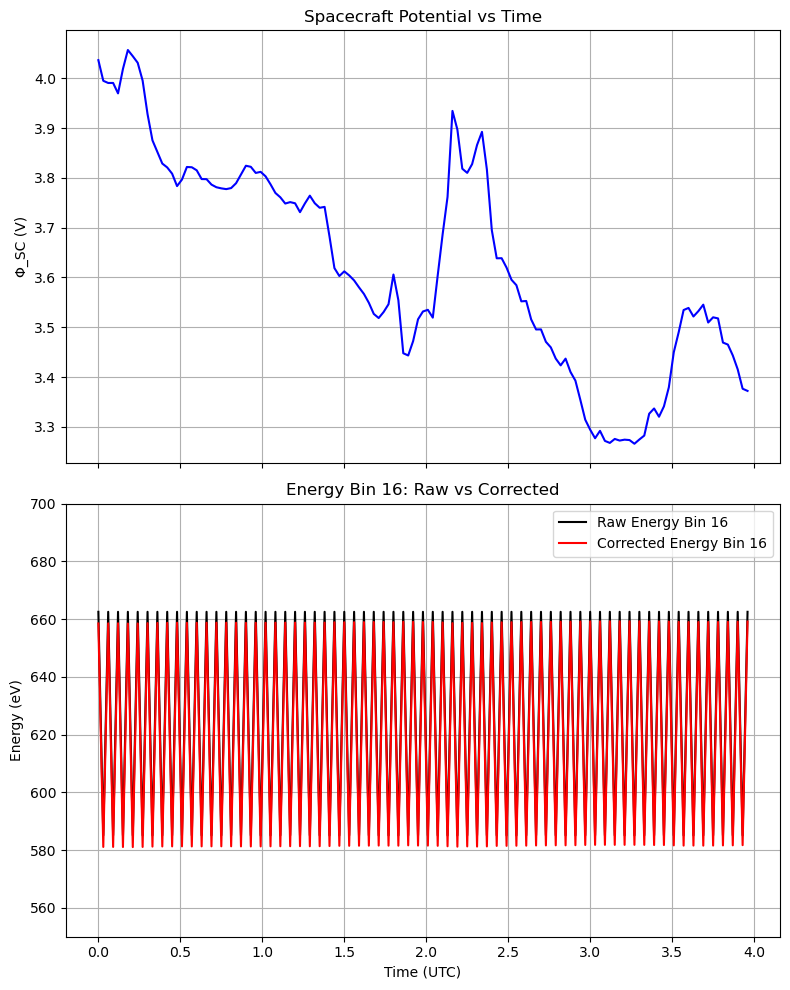

In [24]:
import matplotlib.pyplot as plt

# Create figure and subplots with size equivalent to IDL's window, xs=800, ys=1000
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)

# Plot 1: Spacecraft potential vs time
ax1.plot(times_conv, scpot_reshaped[:, 16], label='Spacecraft Potential', color='blue')
ax1.set_ylabel('Φ_SC (V)')
ax1.set_title('Spacecraft Potential vs Time')
ax1.grid(True)

# Plot 2: Energy bin 16 before and after correction
ax2.plot(times_conv, nrgy[:, 16], label='Raw Energy Bin 16', color='black')
ax2.plot(times_conv, nrgy_corr[:, 16], label='Corrected Energy Bin 16', color='red')
ax2.set_ylabel('Energy (eV)')
ax2.set_ylim(550, 700)  # Equivalent to yr=[550, 700]
ax2.set_title('Energy Bin 16: Raw vs Corrected')
ax2.grid(True)
ax2.legend()

# Common X-axis label
plt.xlabel('Time (UTC)')

# Tight layout for spacing
plt.tight_layout()
plt.show()


In [ ]:
def is_2darr_rep_py(arr, tolerance=1e-6):
    """
    Mimics IDL's is_2darr_rep(arr) by checking if all columns 
    (time steps) are sufficiently close in value to the first column.
    
    Args:
        arr (np.ndarray): The 2D array (EnergyBins x TimeSteps).
        tolerance (float): The maximum allowed difference for equality check.

    Returns:
        bool: True if all columns are essentially the same (interleave OFF), 
              False otherwise.
    """
    if arr.ndim != 2 or arr.shape[1] == 0:
        return True # Treat empty or non-2D as non-interleaved/trivial case

    # Get the first column and reshape it to allow broadcasting across all columns
    first_column = arr[:, 0].reshape(-1, 1)

    # Check if the absolute difference between every element and the corresponding 
    # element in the first column is less than or equal to the tolerance.
    # This directly implements the IDL logic: total(abs( array - testarray) le 1e-6) eq n_elements(array)
    is_close = np.abs(arr - first_column) <= tolerance
    
    return np.all(is_close)

In [7]:
fgm_vars = pyspedas.mms.fgm(trange=trange, probe=1, data_rate='brst',
                            varformat='mms1_fgm_b_gse_brst_l2', time_clip=True)

14-Nov-25 16:48:56: Loading files for group: probe: 1, drate: brst, level: l2, datatype: , after sorting and filtering:
14-Nov-25 16:48:56: /Users/rejohn/Data_Speedas/mms/mms1/fgm/brst/l2/2015/12/09/mms1_fgm_brst_l2_20151209050044_v4.22.0.cdf


In [ ]:
edp_vars = pyspedas.mms.edp(trange=trange,
                            probe=1,
                            data_rate='brst',
                            varnames=['mms1_edp_dce_gse_brst_l2', 'mms1_edp_dce_par_epar_brst_l2'],
                            time_clip=True)

In [ ]:
fpi_vars, fgm_vars, edp_vars

In [ ]:
pyspedas.tplot_rename('mms1_dis_bulkv_gse_brst', 'bulk_vi_gse')
pyspedas.tplot_rename('mms1_des_bulkv_gse_brst', 'bulk_ve_gse')
pyspedas.tplot_rename('mms1_des_numberdensity_brst', 'den_e')
pyspedas.tplot_rename('mms1_fgm_b_gse_brst_l2_bvec', 'bvec_gse')
pyspedas.tplot_rename('mms1_edp_dce_gse_brst_l2', 'evec_gse')
pyspedas.tplot_rename('mms1_edp_dce_par_epar_brst_l2', 'epar_gse')

### Downsampling to DES cadence of 30 ms

In [ ]:
_, den_e = pyspedas.get_data('den_e')
_, bulk_ve = pyspedas.get_data('bulk_ve_gse')
den_e.shape, bulk_ve.shape

In [ ]:
# Define target cadence
des_cadence = 0.03  # seconds or 30 ms

In [ ]:
# 1. Downsample magnetic field (native ~128 Hz → 33 Hz)
pyspedas.avg_data('bvec_gse', res=des_cadence, newname='bvec_gse_avg')

In [ ]:
# 2. Downsample electric field (native 8192 Hz → 33 Hz)
pyspedas.avg_data('evec_gse', res=des_cadence, newname='evec_gse_avg')

In [ ]:
# 3. Downsample parallel electric field (native 8192 Hz → 33 Hz)
pyspedas.avg_data('epar_gse', res=des_cadence, newname='epar_gse_avg')

In [ ]:
# 4. Interpolate ion bulk velocity (native ~6.75 Hz → 33 Hz)
pyspedas.tinterpol( names='bulk_vi_gse', interp_to='bulk_ve_gse', 
                   newname='bulk_vi_gse_interp', method='linear')

In [ ]:
pyspedas.get_units('den_e'), pyspedas.get_units('bulk_ve_gse'), pyspedas.get_units('bulk_vi_gse_interp')

In [ ]:
pyspedas.get_units('evec_gse_avg'), pyspedas.get_units('bvec_gse_avg')

In [ ]:
times, bulk_ve = pyspedas.get_data('bulk_ve_gse')
_, bulk_vi = pyspedas.get_data('bulk_vi_gse_interp')
_, den_e = pyspedas.get_data('den_e')
_, bvec = pyspedas.get_data('bvec_gse_avg')
_, evec = pyspedas.get_data('evec_gse_avg')

In [ ]:
# Converting to SI units
den_e = den_e * 1e6  # Convert from cm^-3 to m^-3
bulk_ve = bulk_ve * 1e3  # Convert from km/s to m/s
bulk_vi = bulk_vi * 1e3  # Convert from km/s to m/s
bvec = bvec * 1e-9  # Convert from nT to T
evec = evec * 1e-3  # Convert from mV/m to V/m

## Calculating $J$:

In [ ]:
from scipy.constants import elementary_charge  # e = 1.602176634e-19 C in SI units
ele_charge = elementary_charge

In [ ]:
jvec_gse = den_e.reshape(-1, 1) * ele_charge * (bulk_vi - bulk_ve)

## Calculating $E^{\prime}$

In [ ]:
bvec.shape, evec.shape

In [ ]:
vxb = np.cross(bvec, evec)

In [ ]:
evec_p_gse = evec + vxb

## Rotating $J$ and $E^{\prime}$ into FAC

In [ ]:
# Computing the FAC rotation matrix
pyspedas.fac_matrix_make(mag_var_name='bvec_gse_avg', other_dim='Xgse', newname='fac_matrix')

In [ ]:
_, fac_matrix = pyspedas.get_data('fac_matrix')

In [ ]:
jvec_gse.shape, evec_p_gse.shape, fac_matrix.shape

In [ ]:
jvec_fac = np.einsum('ijk,ik->ij', fac_matrix, jvec_gse) # J in FAC
evec_p_fac = np.einsum('ijk,ik->ij', fac_matrix, evec_p_gse) # E' in FAC

## Calculating $J \cdot E^{\prime}$

In [ ]:
je_gse = np.einsum('ij,ij->i', jvec_gse, evec_p_gse)  # J·E' in GSE

In [ ]:
je_par_fac = jvec_fac[:, 2] * evec_p_fac[:, 2] # Parallel or z-component JdotE'

In [ ]:
je_perp1_fac = jvec_fac[:, 0] * evec_p_fac[:, 0]
je_perp2_fac = jvec_fac[:, 1] * evec_p_fac[:, 1]

In [ ]:
pyspedas.store_data('je_gse', data={'x': times, 'y': je_gse}, attr_dict={'y': {'units': 'W/m^3', 'label': "J·E' (GSE)"}})
pyspedas.set_coords('je_gse', 'gse')

In [ ]:
pyspedas.store_data('je_par_fac', data={'x': times, 'y': je_par_fac}, attr_dict={'y': {'units': 'W/m^3', 'label': "J·E' Parallel (FAC)"}})
pyspedas.set_coords('je_par_fac', 'fac')

In [ ]:
pyspedas.store_data('je_perp1_fac', data={'x': times, 'y': je_perp1_fac}, attr_dict={'y': {'units': 'W/m^3', 'label': "J·E' Perpendicular 1 (FAC)"}})
pyspedas.set_coords('je_perp1_fac', 'fac')
pyspedas.store_data('je_perp2_fac', data={'x': times, 'y': je_perp2_fac}, attr_dict={'y': {'units': 'W/m^3', 'label': "J·E' Perpendicular 2 (FAC)"}})
pyspedas.set_coords('je_perp2_fac', 'fac')

In [ ]:
# Combine the four tplot variables into one
pyspedas.store_data('combined_je', data=['je_gse', 'je_par_fac',
                                           'je_perp1_fac', 'je_perp2_fac'])

In [ ]:
# Set legend names
pyspedas.options('combined_je', 'legend_names', ['$J \\cdot E^{\\prime}$',
                                                   '$(J \\cdot E^{\\prime})_{\\parallel}$',
                                                   '$(J \\cdot E^{\\prime})_{\\perp 1}$',
                                                   '$(J \\cdot E^{\\prime})_{\\perp 2}$'])

# Set line colors
pyspedas.options('combined_je', 'colors', ['black', 'red', 'blue', 'green'])

# Set line styles (0: solid, 1: dashed, 2: dotted, 3: dash_dot)
pyspedas.options('combined_je', 'line_style', ['solid_line', 'dashed', 'dotted', 'dash_dot'])

# Set line width
pyspedas.options('combined_je', 'line_width', 1.5)

# Set y-axis label
pyspedas.options('combined_je', 'ytitle', '$E_{\\parallel}$')

# Plot
pyspedas.tplot('combined_je', xsize=12, ysize=3.5, 
               save_png='Fig4_Nov7_JdotE_comparison.png')

# pyspedas.tplot(['je_gse', 'je_par_fac', 'je_perp1_fac', 'je_perp2_fac'])